In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/Players.xlsx")
df

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN
...,...,...,...,...,...
561,Younis Khan,1977-11-29,Right_Hand,Right-arm medium,Pakistan
562,YS Chahal,1990-07-23,Right_Hand,Legbreak googly,India
563,Yuvraj Singh,1981-12-12,Left_Hand,Slow left-arm orthodox,India
564,YV Takawale,1984-11-05,Right_Hand,NaN,India


In [3]:
df.head()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [4]:
df.tail()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
561,Younis Khan,1977-11-29,Right_Hand,Right-arm medium,Pakistan
562,YS Chahal,1990-07-23,Right_Hand,Legbreak googly,India
563,Yuvraj Singh,1981-12-12,Left_Hand,Slow left-arm orthodox,India
564,YV Takawale,1984-11-05,Right_Hand,NaN,India
565,Z Khan,1978-10-07,Right_Hand,Left-arm fast-medium,India


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Player_Name    566 non-null    object        
 1   DOB            471 non-null    datetime64[ns]
 2   Batting_Hand   563 non-null    object        
 3   Bowling_Skill  502 non-null    object        
 4   Country        471 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 22.2+ KB


In [7]:
df.shape

(566, 5)

In [8]:
df.isnull().sum()

,0
Player_Name,0
DOB,95
Batting_Hand,3
Bowling_Skill,64
Country,95


In [9]:
df['Batting_Hand'].fillna(df['Batting_Hand'].mode()[0], inplace=True)
df['Bowling_Skill'].fillna(df['Bowling_Skill'].mode()[0], inplace=True)
df['Country'].fillna("Unknown", inplace=True)

/tmp/ipykernel_4753/3491652012.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Batting_Hand'].fillna(df['Batting_Hand'].mode()[0], inplace=True)
/tmp/ipykernel_4753/3491652012.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [10]:
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['DOB'].dt.year

In [11]:
df.describe(include='all')

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country,Age
count,566,471,566,566,566,471.000000
unique,566,NaN,3,16,12,NaN
top,Z Khan,NaN,Right_Hand,Right-arm medium,India,NaN
freq,1,NaN,376,171,264,NaN
mean,NaN,1984-11-15 10:48:09.171974528,NaN,NaN,NaN,41.677282
min,NaN,1969-06-30 00:00:00,NaN,NaN,NaN,28.000000
25%,NaN,1981-05-21 00:00:00,NaN,NaN,NaN,37.000000
50%,NaN,1985-01-25 00:00:00,NaN,NaN,NaN,41.000000
75%,NaN,1989-02-14 12:00:00,NaN,NaN,NaN,45.000000
max,NaN,1998-07-18 00:00:00,NaN,NaN,NaN,57.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
country_count = df['Country'].value_counts()
country_count

,count
Country,
India,264
Unknown,95
Australia,72
South Africa,39
New Zealand,22
Sri Lanka,20
West Indies,19
England,14
Pakistan,13


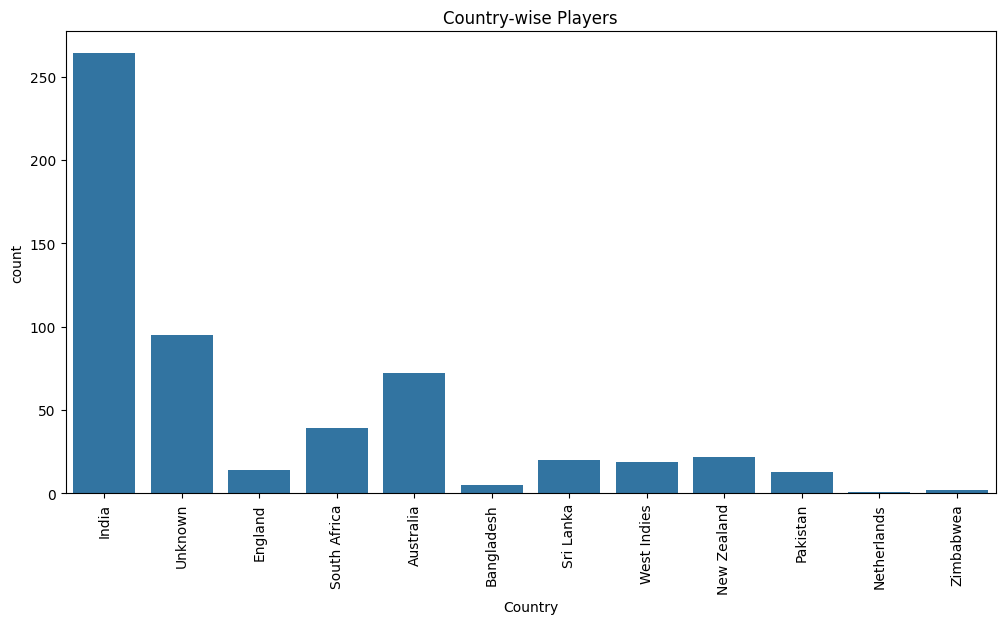

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(x='Country', data=df)
plt.xticks(rotation=90)
plt.title("Country-wise Players")
plt.show()

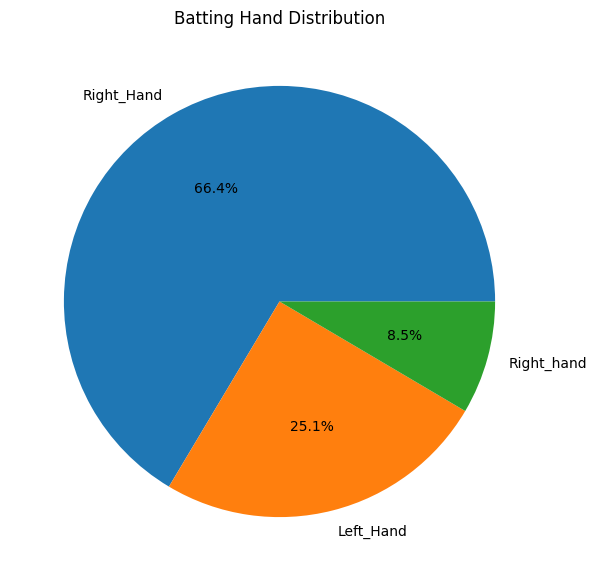

In [16]:
df['Batting_Hand'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.title("Batting Hand Distribution")
plt.ylabel("")
plt.show()

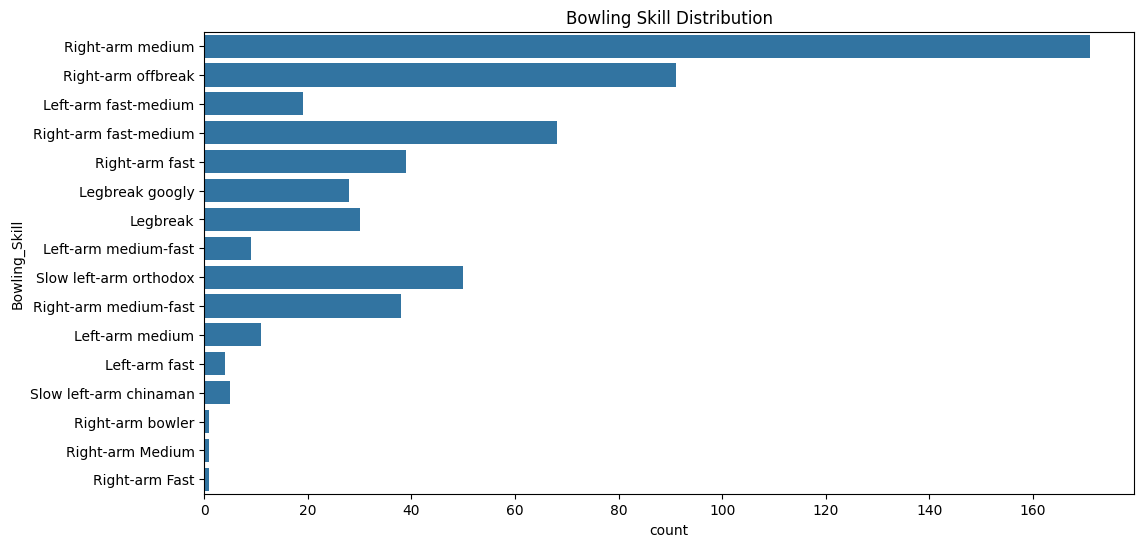

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(y='Bowling_Skill', data=df)
plt.title("Bowling Skill Distribution")
plt.show()

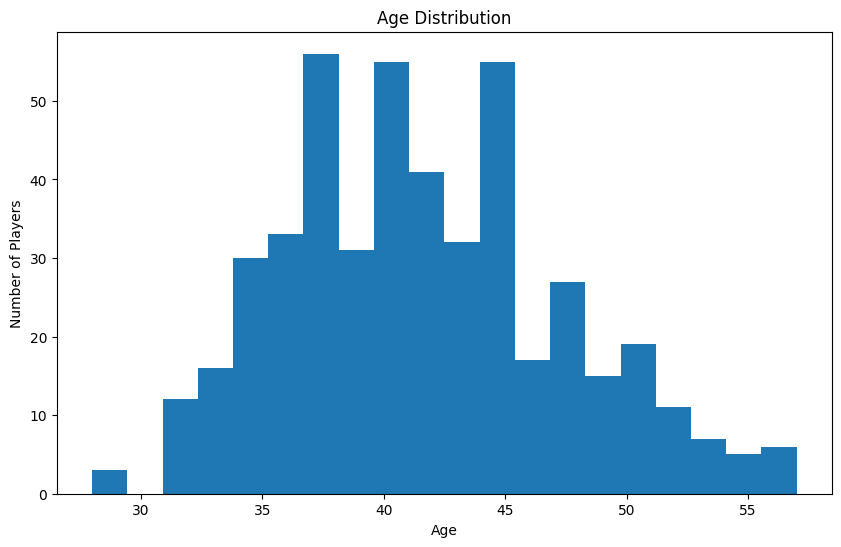

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

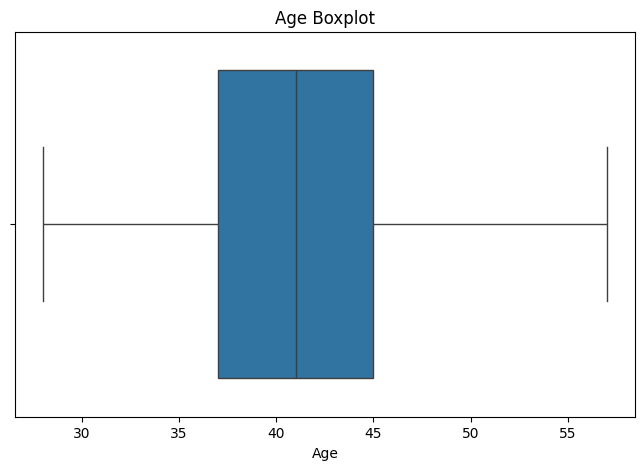

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['Batting_Hand'] = le.fit_transform(df_encoded['Batting_Hand'])
df_encoded['Bowling_Skill'] = le.fit_transform(df_encoded['Bowling_Skill'])
df_encoded['Country'] = le.fit_transform(df_encoded['Country'])

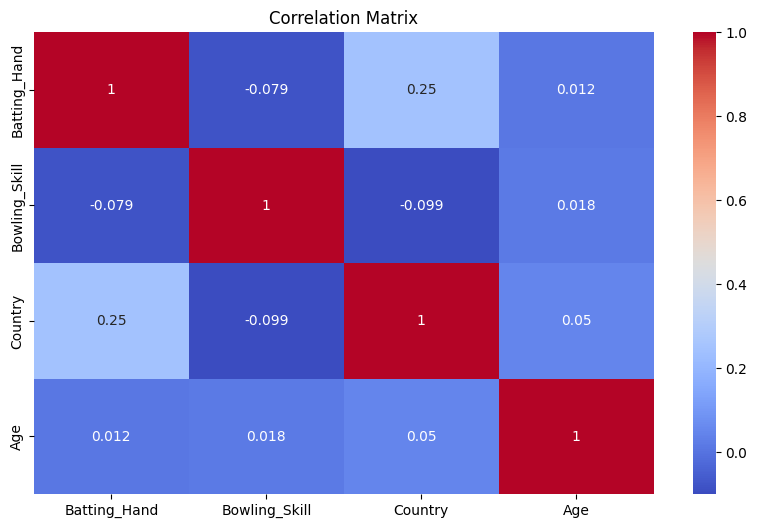

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

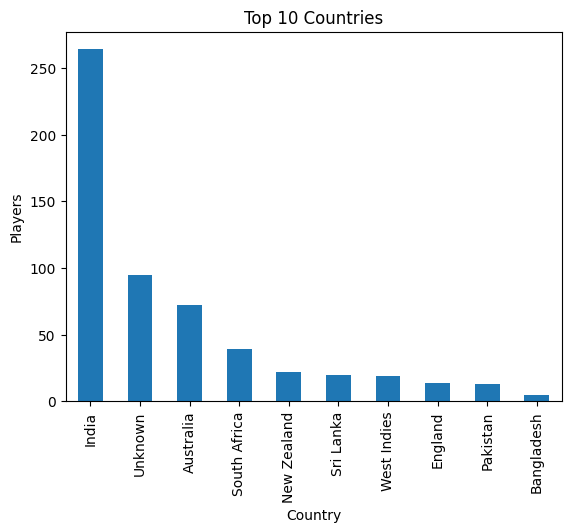

In [22]:
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Players")
plt.show()

In [24]:
df.to_csv("cleaned_players.csv", index=False)

In [25]:
print("Total Players:", len(df))
print("Most Common Batting Hand:")
print(df['Batting_Hand'].mode()[0])
print("Most Common Bowling Skill:")
print(df['Bowling_Skill'].mode()[0])
print("Country with Most Players:")
print(df['Country'].value_counts().idxmax())

Total Players: 566
Most Common Batting Hand:
Right_Hand
Most Common Bowling Skill:
Right-arm medium
Country with Most Players:
India
